In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
results = pd.read_pickle('../sim/data/simulation_results_20260309_095641.pkl')

In [3]:
results.keys()

dict_keys(['runs', 'micro_logs', 'macro_logs', 'opportunity_logs', 'accounts_state', 'opportunities_state', 'leads_state'])

In [4]:
results['runs']['0']['reps']

{'005ak00000TI0yYAAT': {'earnings': 266364.88012892107,
  'strategy': 'Whale Hunter'},
 '005ak00000TI3rZAAT': {'earnings': 274570.49277679593,
  'strategy': 'Volume Chaser'},
 '005ak00000TI49JAAT': {'earnings': 200973.83006395897,
  'strategy': 'Momentum Follower'},
 '005ak00000TI4KbAAL': {'earnings': 223255.4005808556,
  'strategy': 'Steady Closer'}}

In [5]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    # print(accounts)
    # break
#     # build a lookup: account_id -> rep_id
    account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    # print(account_rep)
    for opp_id, opp_data in run_data.get("opportunities", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id") 
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("won"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data['commission'],
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
            
            
        })

# create a DataFrame
opp_df = pd.DataFrame(rows)
    
    
opp_df['run_id'] = opp_df['run_id'].astype(int)

In [6]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    
    # build a lookup: account_id -> rep_id
    # account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    
    for opp_id, opp_data in run_data.get("leads", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id")
        # if opportunity doesn't store account_id, you'll need to map differently
        
        
        
        
        history = opp_data.get("sentiment_history", [])
        n = len(history)

        sentiment_mean = sum(history) / max(n, 1)

        if n > 1:
            sentiment_var = sum((x - sentiment_mean) ** 2 for x in history) / (n - 1)
            sentiment_std = sentiment_var ** 0.5
        else:
            sentiment_std = 0

        
        
        
        
        
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("converted"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data.get('commission', 0),
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
        })

# create a DataFrame
lead_df = pd.DataFrame(rows)
lead_df['run_id'] = lead_df['run_id'].astype(int)

In [7]:
df = pd.concat([lead_df, opp_df])
df = df[
    df['stage_final'].isin(['Closed Lost', 'Closed Won', 'Closed Converted', 'Closed Dead'])
].copy().reset_index(drop = True)

In [8]:
macro = pd.DataFrame(results['macro_logs'])

macro = macro.sort_values(["run_id", "entity_id", "day"])

macro["next_day"] = (
    macro
    .groupby(["run_id", "entity_id"])["day"]
    .shift(-1)
)

macro['days_in_stage'] = macro['next_day'] - macro['day']


micro = pd.DataFrame(results['micro_logs'])

(array([   7.,   27.,  199.,  750., 1605., 1857., 1190.,  465.,  155.,
          25.]),
 array([ 3.2584438 ,  4.04539167,  4.83233954,  5.6192874 ,  6.40623527,
         7.19318314,  7.980131  ,  8.76707887,  9.55402674, 10.34097461,
        11.12792247]),
 <a list of 10 Patch objects>)

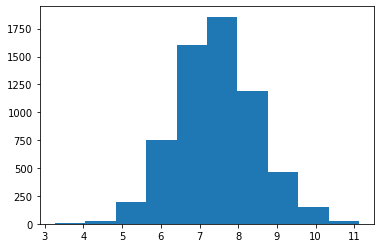

In [9]:
plt.hist(np.log(opp_df['commission']))

In [10]:
macro['new_stage'].value_counts()

Closed Converted    7485
Qualification       6249
Proposal            6170
Negotiation         5257
Prospecting         3785
Closed Won          2887
Closed Lost         2331
Closed Dead          743
Lead                  60
Name: new_stage, dtype: int64

In [11]:
macro['macro_name'].value_counts()

Advance Stage               17676
New Lead                     8119
Close Opportunity            5218
Random Buy Opportunity       3635
Spawn Opportunity            2495
Lead Conversion              2495
Spawn Account                2495
Decay / Lost                  743
Base Opportunity Created      150
Lead Created                   60
Name: macro_name, dtype: int64

In [12]:
micro['action'].value_counts()

send_email               56236
make_call                55579
research_account         55579
hold_meeting             21288
follow_up                21122
send_proposal            19433
internal_prep            15486
solution_design          11896
stakeholder_alignment     5883
Name: action, dtype: int64

(array([26687.,  8908., 14382., 28764., 54139., 56382., 30122., 13919.,
         7563., 18584.]),
 array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5]),
 <a list of 10 Patch objects>)

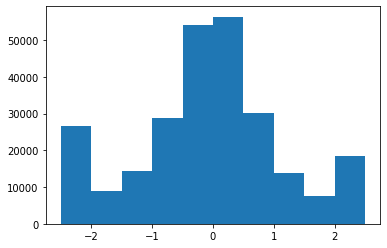

In [13]:
plt.hist(micro['sentiment_delta'])

(array([26576.,  7005., 13814., 33370., 58702., 56105., 29046., 13331.,
         6507., 14994.]),
 array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <a list of 10 Patch objects>)

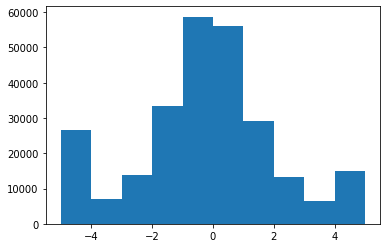

In [14]:
plt.hist(micro['sentiment_total'])

Advance Stage


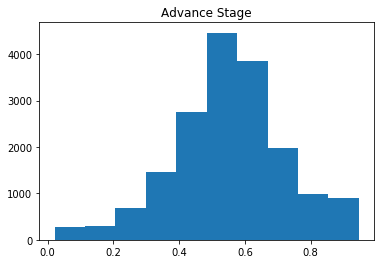

Close Opportunity


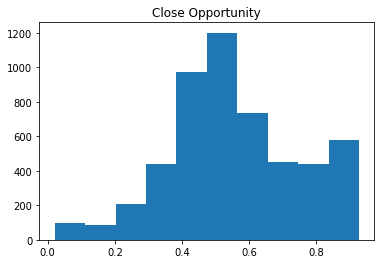

Decay / Lost


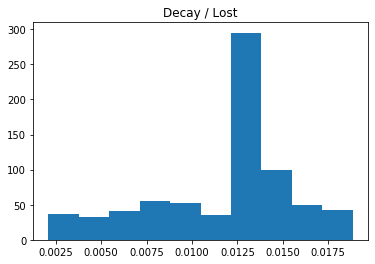

Lead Conversion


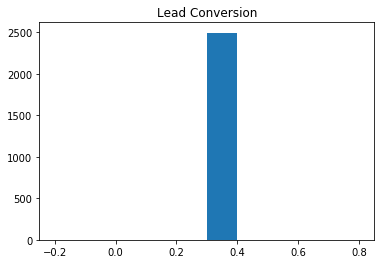

In [15]:
for m in ['Advance Stage', 'Close Opportunity', 'Decay / Lost', 'Lead Conversion']:
    print(m)
    plt.hist(macro[macro['macro_name'] == m]['probability'])
    plt.title(m)
    plt.show()

In [16]:
# crash()

(array([1082.,  348.,  821., 9260., 3608., 5750., 4792., 2562., 1484.,
        1415.]),
 array([0.0021    , 0.09657086, 0.19104172, 0.28551258, 0.37998344,
        0.47445429, 0.56892515, 0.66339601, 0.75786687, 0.85233773,
        0.94680859]),
 <a list of 10 Patch objects>)

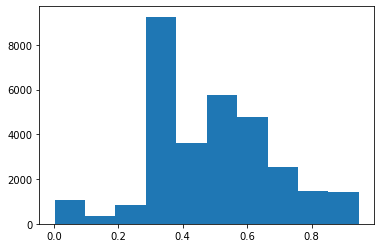

In [17]:
plt.hist(macro['probability'])

In [18]:
micro.groupby("action")["entity_id"].min()

action
follow_up                000122c3-82c8-43f8-a057-f8848f04a03d
hold_meeting             000122c3-82c8-43f8-a057-f8848f04a03d
internal_prep            000122c3-82c8-43f8-a057-f8848f04a03d
make_call                000122c3-82c8-43f8-a057-f8848f04a03d
research_account         000122c3-82c8-43f8-a057-f8848f04a03d
send_email               000122c3-82c8-43f8-a057-f8848f04a03d
send_proposal            000122c3-82c8-43f8-a057-f8848f04a03d
solution_design          000122c3-82c8-43f8-a057-f8848f04a03d
stakeholder_alignment    000122c3-82c8-43f8-a057-f8848f04a03d
Name: entity_id, dtype: object

In [19]:
for i in df['run_id'].unique():
    df_temp = df[df['run_id'] == i].copy()
    break

In [20]:
opp_rows = [
    # 'opportunity_id',
    # 'rep_id',
    # 'revenue',
    # 'stage_history' '(days in stage)',
    'activity_count',
    'avg activity per day',
    'avg activity per stage'
    'cycle_time',
    'median_sentiment',
    'initial_sentiment',
    'final_sentiment',
    'std_sentiment',
    'closed_won'
]

In [21]:
opps = []
oppsdfds = 0

for run_id in tqdm(range(15)):

    run_df = df[df['run_id'] == run_id].copy()
    run_macro = macro[macro['run_id'] == run_id].copy()
    run_micro = micro[micro['run_id'] == run_id].copy()

    sim_end = run_macro["day"].max()

    for op in run_df['opportunity_id'].unique():
        won = run_df[run_df['opportunity_id'] == op]['won'].values[0]
        opp_df = run_df[run_df['opportunity_id'] == op]
        rep_id = opp_df['rep_id'].values[0]
        revenue = opp_df['revenue'].values[0]
        commish = opp_df['commission'].values[0]
        # -----------------------------
        # Macro slice for this opp
        # -----------------------------
        stages = (
            run_macro[run_macro['entity_id'] == op]
            .sort_values("day")
            .reset_index(drop=True)
        )

        if stages.empty:
            continue

        # Logical stages
        if stages['macro_name'].str.contains("Lead").any():
            stages_real = stages.iloc[[0]]
        else:
            stages_real = (
                stages[~stages['new_stage'].str.contains("Closed", na=False)]
                .groupby("new_stage", as_index=False)
                .agg({"day": "min"})
            )

        n_stages = len(stages_real)

        # -----------------------------
        # Micro slice for this opp
        # -----------------------------
        micro_opp = run_micro[run_micro['entity_id'] == op]
        activity_count = len(micro_opp)

        # -----------------------------
        # Compute micro actions per stage window
        # -----------------------------
        activity_per_stage = []
        stage_days = stages_real["day"].values.tolist() + [sim_end]

        for i in range(n_stages):
            start_day = stage_days[i]
            end_day = stage_days[i + 1]

            n_micro = micro_opp[
                (micro_opp["day"] >= start_day) &
                (micro_opp["day"] < end_day)
            ].shape[0]

            activity_per_stage.append(n_micro)

        avg_micro_per_stage = np.mean(activity_per_stage) if activity_per_stage else 0
        stage_days_diff = np.diff(stage_days)
        avg_days_in_stage = np.mean(stage_days_diff) if len(stage_days_diff) > 0 else 0

        # -----------------------------
        # Cycle time (first to last touch)
        # -----------------------------
        macro_days = stages['day'].values
        cycle_time = macro_days.max() - macro_days.min() if len(macro_days) > 0 else 0

        # -----------------------------
        # Sentiment
        # -----------------------------
        hist_lists = opp_df['sentiment_history'].tolist()
        all_history = [s for sublist in hist_lists for s in sublist]

        sentiment_median = np.median(all_history) if all_history else np.nan
        sentiment_std = np.std(all_history, ddof=1) if len(all_history) > 1 else 0.0
        final_sentiment = opp_df['sentiment'].values[-1]

        # -----------------------------
        # Store results
        # -----------------------------
        opps.append({
            'run_id': run_id,
            'entity': f'{op}_{oppsdfds}',
            'rep_id': rep_id,
            'revenue': revenue,
            'commission': commish,
            'n_stages': n_stages,
            'avg_days_in_stage': avg_days_in_stage,
            'activity_count': activity_count,
            'avg_micro_per_stage': avg_micro_per_stage,
            'cycle_time': cycle_time,
            'final_sentiment': final_sentiment,
            'sentiment_median': sentiment_median,
            'sentiment_std': sentiment_std,
            'won':won
        })
        oppsdfds += 1

100%|██████████| 15/15 [01:34<00:00,  6.32s/it]


In [22]:
df = pd.DataFrame(opps)

In [23]:
df['revenue'].max()

69911549.6460588

In [24]:
for rep, opps in df.groupby('rep_id'):
    print(rep_id)
    print((opps['revenue'].mean()))
    print(len(opps[opps['won'] == True]) / len(opps))
    print()
    print()

005ak00000TI0yYAAT
2908313.227691274
0.41655359565807326


005ak00000TI0yYAAT
3066702.339305367
0.3742663656884876


005ak00000TI0yYAAT
2801059.9154261816
0.523853635942566


005ak00000TI0yYAAT
2656975.778793728
0.39777111015859407




(array([5.139e+03, 2.180e+02, 1.700e+01, 4.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  1. ,  71.6, 142.2, 212.8, 283.4, 354. , 424.6, 495.2, 565.8,
        636.4, 707. ]),
 <a list of 10 Patch objects>)

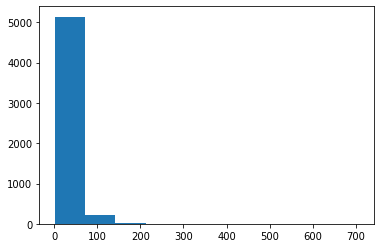

In [25]:
plt.hist(df[df['won'] == True]['activity_count'])

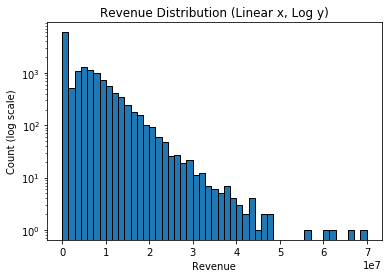

In [26]:
import numpy as np
import matplotlib.pyplot as plt

data = df['revenue']
data = data[data > 0]

# Use linear bins
bins = np.linspace(data.min(), data.max(), 50)  # 50 bins evenly spaced in linear space

plt.hist(data, bins=bins, edgecolor='k')
plt.yscale('log')  # optional
plt.xlabel('Revenue')
plt.ylabel('Count (log scale)')
plt.title('Revenue Distribution (Linear x, Log y)')
plt.show()

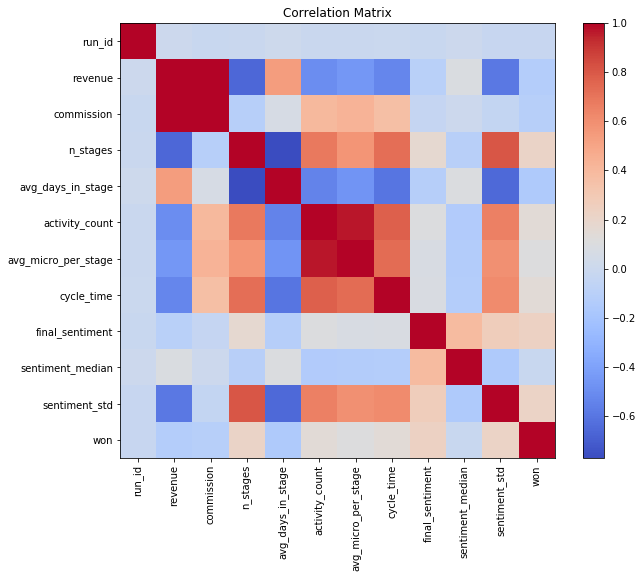

In [27]:
# =========================================
# 2️⃣ DESCRIPTIVE ANALYSIS (PLT & NP)
# =========================================

# Correlation matrix
corr = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


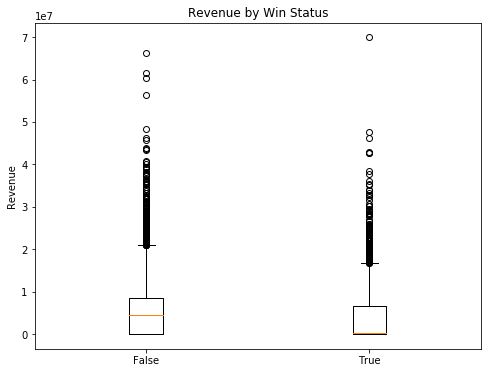

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


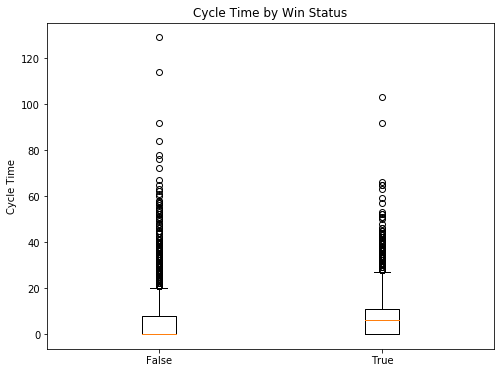

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


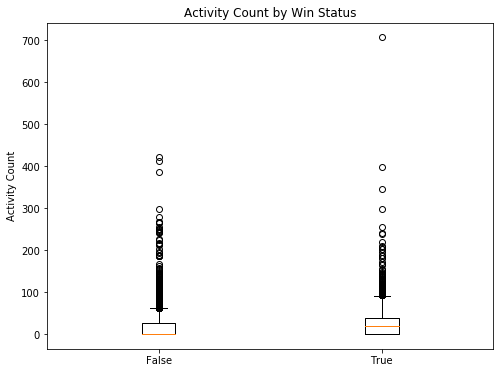

/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


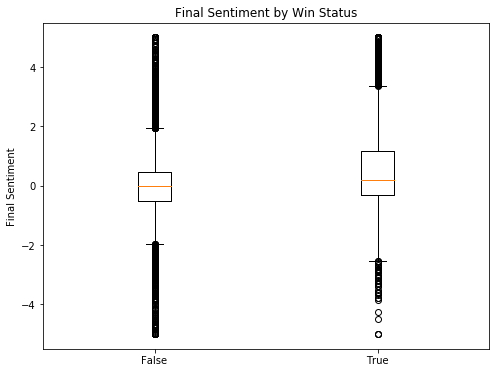

In [28]:
# Boxplot function using plt
def boxplot_manual(x, y, title, ylabel):
    labels = np.unique(x)
    data_to_plot = [y[x == lbl] for lbl in labels]
    plt.figure(figsize=(8,6))
    plt.boxplot(data_to_plot, labels=labels)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.show()

# Revenue by win
boxplot_manual(df['won'].values, df['revenue'].values, "Revenue by Win Status", "Revenue")

# Cycle time by win
boxplot_manual(df['won'].values, df['cycle_time'].values, "Cycle Time by Win Status", "Cycle Time")

# Activity count by win
boxplot_manual(df['won'].values, df['activity_count'].values, "Activity Count by Win Status", "Activity Count")

# Final sentiment by win
boxplot_manual(df['won'].values, df['final_sentiment'].values, "Final Sentiment by Win Status", "Final Sentiment")

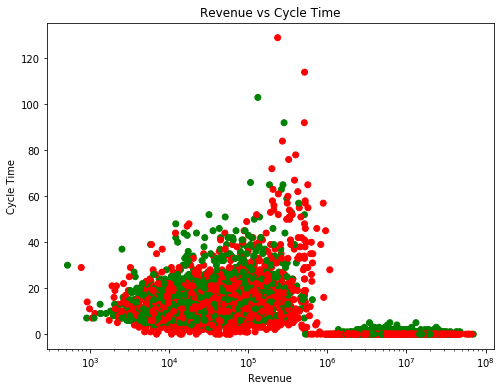

In [29]:
# Scatterplot function
def scatter_manual(x, y, color=None, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(8,6))
    if color is None:
        color = 'b'
    plt.scatter(x, y, c=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xscale('log')
    # plt.yscale('log')
    # plt.legend()
    plt.show()

# Revenue vs cycle_time colored by win
colors = np.array(['red','green'])
scatter_manual(df['revenue'].values, df['cycle_time'].values, color=colors[df['won'].astype(int).values],
               title="Revenue vs Cycle Time", xlabel="Revenue", ylabel="Cycle Time")

In [30]:
df[df['won'] == True]

,run_id,entity,rep_id,revenue,commission,n_stages,avg_days_in_stage,activity_count,avg_micro_per_stage,cycle_time,final_sentiment,sentiment_median,sentiment_std,won
2,0,4UUT87JT_2,005ak00000TI0yYAAT,1.308275e+07,NaN,1,300.00,1,1.00,1,-0.444216,-0.444216,0.000000,True
5,0,PYR1GY44_5,None,4.371233e+06,NaN,1,299.00,1,1.00,0,-0.052471,-0.052471,0.000000,True
13,0,9ADCWPUZ_13,None,1.629430e+06,NaN,1,299.00,1,1.00,0,0.096520,0.096520,0.000000,True
16,0,MIERF3F1_16,None,2.701232e+06,NaN,1,299.00,1,1.00,0,-0.464926,-0.464926,0.000000,True
20,0,49MTBPXR_20,005ak00000TI0yYAAT,4.195683e+06,NaN,1,299.00,1,1.00,1,0.973100,0.973100,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14131,14,b65d3f0e-8143-4636-801a-2af98647e38a_14131,005ak00000TI0yYAAT,7.918264e+04,3959.131951,4,0.75,22,5.50,13,-0.438657,-0.181000,0.662218,True
14132,14,c7473d7f-0518-407a-ba67-eaea8d8bb3f6_14132,005ak00000TI49JAAT,1.719935e+04,859.967596,4,0.75,51,12.75,13,2.566516,-0.175000,1.791819,True
14134,14,30fc01f3-6bb1-437e-b2b8-abe95f15d570_14134,005ak00000TI49JAAT,1.232859e+05,6164.296018,4,0.50,51,12.75,11,3.889852,0.895133,1.867767,True
14138,14,b143a033-ecaa-4027-9246-e218856058c4_14138,005ak00000TI4KbAAL,2.832220e+04,1416.110032,4,0.00,35,8.25,6,3.306151,0.200485,0.735604,True


In [31]:
df['commission_pct'] = df['commission'] / df['revenue']

In [32]:
df['commission_pct'].mean()

0.05000034930943648

In [33]:
df['commission_pct'].std()

2.6854606489638263e-05

In [34]:
df['commission_pct'].max()

0.052073336095077895

In [35]:
df['commission_pct'].min()

0.04999774681209123

In [36]:
df['commission'].mean()

2894.571649406312

In [37]:
df['commission'].std()

4051.676580433862

In [38]:
df['commission'].min()

26.009030446626248

In [39]:
df['commission'].max()

55939.38

(array([5.256e+03, 4.760e+02, 1.230e+02, 4.300e+01, 4.200e+01, 1.200e+01,
        3.000e+00, 3.000e+00, 2.000e+00, 1.000e+00]),
 array([2.60090304e+01, 5.61734613e+03, 1.12086832e+04, 1.68000203e+04,
        2.23913574e+04, 2.79826945e+04, 3.35740316e+04, 3.91653687e+04,
        4.47567058e+04, 5.03480429e+04, 5.59393800e+04]),
 <a list of 10 Patch objects>)

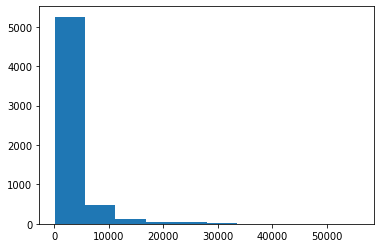

In [40]:
plt.hist(df['commission'])

In [44]:
# =========================================
# 3️⃣ REP-LEVEL PERFORMANCE
# =========================================
rep_summary = df.groupby('rep_id').agg(
    win_rate=('won', 'mean'),
    avg_revenue=('revenue', 'mean'),
        avg_commission=('commission', 'mean'),

    avg_cycle=('cycle_time', 'mean'),
    avg_activity=('activity_count', 'mean'),
    avg_sentiment=('final_sentiment', 'mean'),
    total_opps=('entity', 'count'),
).sort_values('win_rate', ascending=False)

print("\nRep-level Summary:")
print(rep_summary)


Rep-level Summary:
                    win_rate   avg_revenue  avg_commission  avg_cycle  \
rep_id                                                                  
005ak00000TI49JAAT  0.523854  2.801060e+06     2346.814977   8.826772   
005ak00000TI0yYAAT  0.416554  2.908313e+06     3120.674441   8.226142   
005ak00000TI4KbAAL  0.397771  2.656976e+06     2745.246944   8.746678   
005ak00000TI3rZAAT  0.374266  3.066702e+06     3392.485336   8.806321   

                    avg_activity  avg_sentiment  total_opps  
rep_id                                                       
005ak00000TI49JAAT     28.928208       0.915651        2159  
005ak00000TI0yYAAT     27.528720       0.359360        2211  
005ak00000TI4KbAAL     26.924132       0.033602        2333  
005ak00000TI3rZAAT     27.689391       0.033670        2215  
